In [ ]:
import os
import torch
from PIL import Image
from torchvision import transforms
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import Dataset , DataLoader
from torchvision import transforms , models
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn

In [49]:
data1_images = r"F:\عریشیاس\ml\emergency_dataset_with_label\data1\images"
data1_labels = r"F:\عریشیاس\ml\emergency_dataset_with_label\data1\labels"

data2_images = r"F:\عریشیاس\ml\emergency_dataset_with_label\data2\images"
data2_labels = r"F:\عریشیاس\ml\emergency_dataset_with_label\data2\labels"

In [50]:
def read_label(label_path, image_width, image_height):

    boxes = []

    with open(label_path, "r") as f:

        for line in f:
            values = line.strip().split()

            if len(values) != 9:
                continue

            class_id = int(values[0])

            coords = list(map(float, values[1:]))

            x1 = min(coords[0], coords[2], coords[4], coords[6])
            y1 = min(coords[1], coords[3], coords[5], coords[7])

            x2 = max(coords[0], coords[2], coords[4], coords[6])
            y2 = max(coords[1], coords[3], coords[5], coords[7])

            x1 = int(x1 * image_width)
            y1 = int(y1 * image_height)

            x2 = int(x2 * image_width)
            y2 = int(y2 * image_height)

            boxes.append((class_id, x1, y1, x2, y2))

    return boxes

In [51]:
image_name = os.listdir(data1_images)[0]

image_path = os.path.join(data1_images, image_name)

label_name = os.path.splitext(image_name)[0] + ".txt"
label_path = os.path.join(data1_labels, label_name)

image = Image.open(image_path)

width, height = image.size

boxes = read_label(label_path, width, height)

print("Image size:", image.size)
print("Boxes:", boxes)

Image size: (848, 480)
Boxes: [(1, 238, 6, 477, 141), (1, 31, 23, 261, 222), (1, 3, 160, 150, 451), (1, 341, 312, 609, 472), (1, 669, 233, 835, 458)]


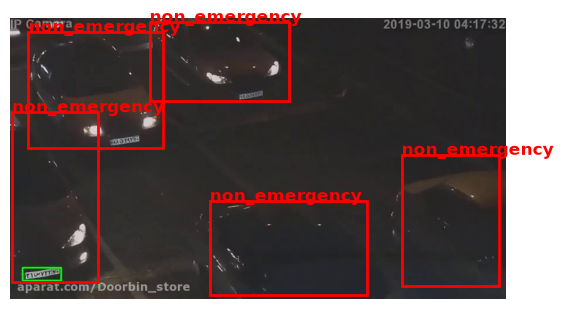

In [52]:
fig, ax = plt.subplots()

ax.imshow(image)

for class_id, x1, y1, x2, y2 in boxes:

    if class_id == 0:
        color = "green"
        label = "emergency"
    else:
        color = "red"
        label = "non_emergency"

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        edgecolor=color,
        linewidth=2
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        label,
        color=color,
        fontsize=12,
        fontweight="bold"
    )

plt.axis("off")
plt.show()

In [53]:
def crop_objects(image_path, label_path):

    image = Image.open(image_path).convert("RGB")

    width, height = image.size

    boxes = read_label(
        label_path,
        width,
        height
    )

    crops = []

    for class_id, x1, y1, x2, y2 in boxes:

        crop = image.crop((x1, y1, x2, y2))

        crops.append({
            "image": crop,
            "label": class_id
        })

    return crops

Number of cars: 5
Label: non_emergency Size: (239, 135)


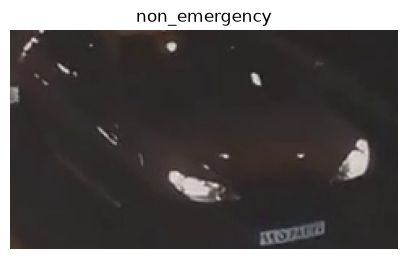

Label: non_emergency Size: (230, 199)


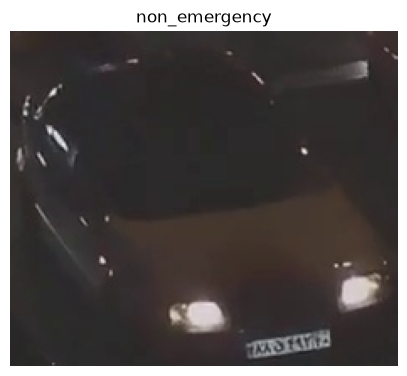

Label: non_emergency Size: (147, 291)


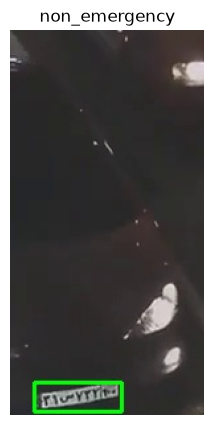

Label: non_emergency Size: (268, 160)


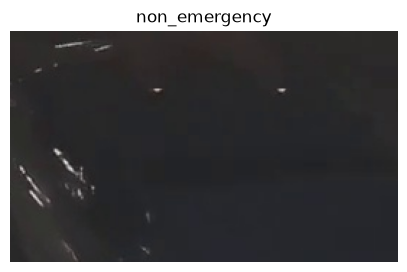

Label: non_emergency Size: (166, 225)


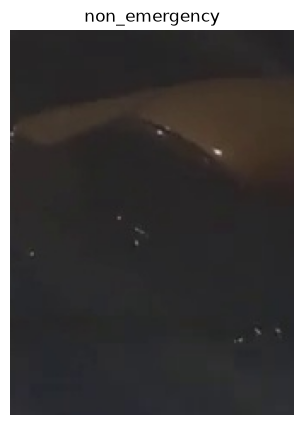

In [54]:
crops = crop_objects(
    image_path,
    label_path
)

print("Number of cars:", len(crops))

for item in crops:
    print(
        "Label:",
        "emergency" if item["label"] == 0 else "non_emergency",
        "Size:",
        item["image"].size
    )
    plt.figure(figsize=(5, 5))

    plt.imshow(item["image"])

    label = (
        "emergency"
        if item["label"] == 0
        else "non_emergency"
    )

    plt.title(label)

    plt.axis("off")

    plt.show()

In [55]:
def create_crops(images_folder, labels_folder):

    data = []

    image_files = os.listdir(images_folder)

    for image_name in image_files:

        image_path = os.path.join(
            images_folder,
            image_name
        )

        label_name = os.path.splitext(image_name)[0] + ".txt"

        label_path = os.path.join(
            labels_folder,
            label_name
        )

        if not os.path.exists(label_path):
            continue

        crops = crop_objects(
            image_path,
            label_path
        )

        data.extend(crops)

    return data

In [ ]:
data1 = create_crops(
    data1_images,
    data1_labels
)

data2 = create_crops(
    data2_images,
    data2_labels
)

data = data1 + data2

print("Total samples:", len(data))
print("Data1 crops:", len(data1))
print("Data2 crops:", len(data2))
print("Total:", len(data))
print(Counter(item["label"] for item in data))

Total samples: 1775
Data1 crops: 428
Data2 crops: 1347
Total: 1775
Counter({1: 1491, 0: 284})


In [62]:
images = [item["image"] for item in data]
labels = [item["label"] for item in data]
X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 1242
Validation: 266
Test: 267


In [64]:
class VehicleDataset(Dataset):

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image = self.images[index]
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

In [70]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = VehicleDataset(
    X_train,
    y_train,
    transform=train_transform
)

val_dataset = VehicleDataset(
    X_val,
    y_val,
    transform=val_test_transform
)

test_dataset = VehicleDataset(
    X_test,
    y_test,
    transform=val_test_transform
)
image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
1


In [72]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)
images_batch, labels_batch = next(iter(train_loader))

print(images_batch.shape)
print(labels_batch.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [76]:
model = models.resnet18(weights="DEFAULT")
model.fc = nn.Linear(
    model.fc.in_features,
    2
)
print(model.fc)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)

Linear(in_features=512, out_features=2, bias=True)
Device: cpu


In [80]:
model = model.to(device)

class_weights = torch.tensor(
    [
        1775 / (2 * 284),
        1775 / (2 * 1491)
    ],
    dtype=torch.float
)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

Class weights: tensor([3.1250, 0.5952])


In [81]:
num_epochs = 3

for epoch in range(num_epochs):

    # =========================
    # TRAIN
    # =========================

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_acc = train_correct / train_total


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_acc = val_correct / val_total


    # =========================
    # RESULTS
    # =========================

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/3] Train Loss: 0.1881 Train Acc: 0.9050 Val Loss: 0.0838 Val Acc: 0.9887
Epoch [2/3] Train Loss: 0.0318 Train Acc: 0.9887 Val Loss: 0.0671 Val Acc: 0.9962
Epoch [3/3] Train Loss: 0.0385 Train Acc: 0.9903 Val Loss: 0.0682 Val Acc: 0.9850


In [83]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)
print(f"Test Accuracy: {test_accuracy:.4f}")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Emergency",
            "Non-Emergency"
        ]
    )
)
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

Test Accuracy: 0.9963
               precision    recall  f1-score   support

    Emergency       0.98      1.00      0.99        43
Non-Emergency       1.00      1.00      1.00       224

     accuracy                           1.00       267
    macro avg       0.99      1.00      0.99       267
 weighted avg       1.00      1.00      1.00       267

[[ 43   0]
 [  1 223]]


In [ ]:
def predict_vehicle(image_path):

    image = Image.open(image_path).convert("RGB")

    image = val_test_transform(image)

    image = image.unsqueeze(0)

    image = image.to(device)

    model.eval()

    with torch.no_grad():

        output = model(image)

        _, predicted = torch.max(output, 1)

    class_id = predicted.item()

    if class_id == 0:
        result = "Emergency"
    else:
        result = "Non-Emergency"

    print("Prediction:", result)

    return result

paste your photo address

In [89]:
predict_vehicle(
    r"C:\Users\Arshia\Downloads\images (2).jpg"
)

Prediction: Emergency


'Emergency'